<a href="https://colab.research.google.com/github/epleywin/ECON3916-Statistical-Machine-Learning/blob/main/Project%205/%20Project_5_Epley_Win.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


In [49]:
# ============================================================
# PART 1A: Download World Bank Data
# ============================================================

# WDI indicator codes for our predictors
# Format: 'indicator_code': 'human_readable_name'
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

# Download 7 years of data (2013–2019, pre-COVID) and average
# wb.data.DataFrame returns a DataFrame indexed by (economy, time) or (economy)
try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")
    # Fallback: load pre-downloaded CSV
    # raw_data = pd.read_csv('data/fallback_wdi_topic16.csv', index_col=[0, 1])

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7211, 7)
Download successful ✓


In [50]:
data = raw_data.stack().reset_index()
data.columns = ['economy', 'time', 'indicator', 'value']

data['indicator'] = data['indicator'].map(INDICATORS)

data = data.dropna(subset=['indicator'])

data_pivot = data.pivot_table(
    index=['economy', 'time'],
    columns='indicator',
    values='value'
)

data = raw_data.stack().reset_index()

data.columns = ['economy', 'indicator', 'year', 'value']

data['indicator'] = data['indicator'].map(INDICATORS)

data = data.dropna(subset=['indicator'])

data_pivot = data.pivot_table(
    index=['economy', 'year'],
    columns='indicator',
    values='value'
)

country_data = data_pivot.groupby('economy').mean()

if 'gdp_growth_pc' not in country_data.columns:
    print("Fixing GDP growth...")
    gdp_data = wb.data.DataFrame('NY.GDP.PCAP.KD.ZG', time=range(2013, 2020))
    gdp_avg = gdp_data.groupby(level='economy').mean().mean(axis=1)
    country_data['gdp_growth_pc'] = gdp_avg

country_data = country_data[country_data.isnull().mean(axis=1) < 0.4]

country_data = country_data.loc[:,
    (country_data.isnull().mean() < 0.4) | (country_data.columns == 'gdp_growth_pc')
]

country_data = country_data.fillna(country_data.median())

country_data['crisis'] = (country_data['gdp_growth_pc'] < 0).astype(int)

In [51]:
print(country_data.columns)

Index(['adult_literacy_rate', 'agriculture_pct_gdp', 'arable_land_pct',
       'atms_per100k', 'current_account_pct_gdp',
       'education_expenditure_pct_gdp', 'electricity_access_pct',
       'exchange_rate_official', 'fdi_inflows_pct_gdp', 'gdp_growth_pc',
       'govt_expenditure_pct_gdp', 'health_expenditure_pct_gdp',
       'infant_mortality_per1000', 'inflation_cpi', 'internet_users_pct',
       'life_expectancy', 'mobile_subscriptions_per100',
       'natural_resource_rents_pct_gdp', 'population_growth',
       'private_credit_pct_gdp', 'renewable_energy_pct', 'royalties_receipts',
       'secondary_enrollment_gross', 'tariff_rate_avg',
       'tertiary_enrollment_gross', 'trade_pct_gdp', 'unemployment_rate',
       'urbanization_pct', 'crisis'],
      dtype='object', name='indicator')


In [52]:
y = country_data['gdp_growth_pc']
country_data['crisis'] = (country_data['gdp_growth_pc'] < 0).astype(int)

In [53]:
X = country_data.drop(columns=['gdp_growth_pc', 'crisis'])
X = X.select_dtypes(include=[np.number])

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
print("Final dataset shape:", country_data.shape)

n_crisis = country_data['crisis'].sum()
n_total = len(country_data)

print("Crisis countries:", n_crisis)
print("Non-crisis countries:", n_total - n_crisis)
print("Crisis base rate:", round(n_crisis / n_total, 3))

Final dataset shape: (235, 29)
Crisis countries: 36
Non-crisis countries: 199
Crisis base rate: 0.153


In [57]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [58]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [59]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training R²:", round(train_r2, 4))
print("Test R²:", round(test_r2, 4))

Training R²: 0.4808
Test R²: 0.1575


In [60]:
r2_gap = train_r2 - test_r2
print("Train-Test R² Gap:", round(r2_gap, 4))

Train-Test R² Gap: 0.3233


In [61]:
p = X_train.shape[1]
n = X_train.shape[0]

print("Number of predictors (p):", p)
print("Number of observations (n):", n)
print("p/n ratio:", round(p/n, 4))

Number of predictors (p): 27
Number of observations (n): 164
p/n ratio: 0.1646


The training R² is substantially higher than the test R², creating a noticeable gap that suggests the model is overfitting the training data. With a relatively high p/n ratio of about 0.16, the model has enough degrees of freedom to fit noise in the training set, which increases variance and hurts generalization. While OLS benefits from low bias, this flexibility comes at the cost of higher variance, leading to weaker performance on unseen data.

In [62]:
ridge = RidgeCV(alphas=np.logspace(-4, 4, 100), cv=5)
ridge.fit(X_train_scaled, y_train)

ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_test_pred))

print("RIDGE")
print("Alpha:", ridge.alpha_)
print("Train R²:", ridge_train_r2)
print("Test R²:", ridge_test_r2)

RIDGE
Alpha: 95.45484566618347
Train R²: 0.36309987993706383
Test R²: 0.30389893732765483


In [63]:
lasso = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)

lasso_train_r2 = r2_score(y_train, lasso_train_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_test_pred))

print("LASSO")
print("Alpha:", lasso.alpha_)
print("Train R²:", lasso_train_r2)
print("Test R²:", lasso_test_r2)

LASSO
Alpha: 0.09545484566618337
Train R²: 0.39402798590878885
Test R²: 0.26467971421064385


In [64]:
ridge_nonzero = np.sum(np.abs(ridge.coef_) > 1e-6)
lasso_nonzero = np.sum(np.abs(lasso.coef_) > 1e-6)

ols_nonzero = X_train.shape[1]

print("OLS non-zero:", ols_nonzero)
print("Ridge non-zero:", ridge_nonzero)
print("Lasso non-zero:", lasso_nonzero)

OLS non-zero: 27
Ridge non-zero: 27
Lasso non-zero: 17


In [65]:
results = pd.DataFrame({
    "Model": ["OLS", "RidgeCV", "LassoCV"],
    "Lambda (alpha)": [None, ridge.alpha_, lasso.alpha_],
    "Non-zero Predictors": [
        ols_nonzero,
        ridge_nonzero,
        lasso_nonzero
    ],
    "Train R²": [
        train_r2,
        ridge_train_r2,
        lasso_train_r2
    ],
    "Test R²": [
        test_r2,
        ridge_test_r2,
        lasso_test_r2
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        ridge_rmse,
        lasso_rmse
    ]
})

print(results)

     Model  Lambda (alpha)  Non-zero Predictors  Train R²   Test R²  Test RMSE
0      OLS             NaN                   27  0.480799  0.157461   2.486060
1  RidgeCV       95.454846                   27  0.363100  0.303899   2.259711
2  LassoCV        0.095455                   17  0.394028  0.264680   2.322496


I would recommend Ridge regression for GDP growth forecasting because it achieves the best test performance while maintaining stability across training and test data. Compared to OLS, Ridge reduces variance by shrinking coefficients, which improves generalization at the cost of a small increase in bias. Lasso also reduces variance by selecting a smaller subset of predictors, but it sacrifices more information than Ridge, which slightly limits its predictive performance in this case.

In [66]:
X_train_np = X_train_scaled
y_train_np = y_train.values

In [67]:
from sklearn.linear_model import lasso_path

alphas, coefs, _ = lasso_path(X_train_np, y_train_np)

In [68]:
lasso_alpha_star = lasso.alpha_

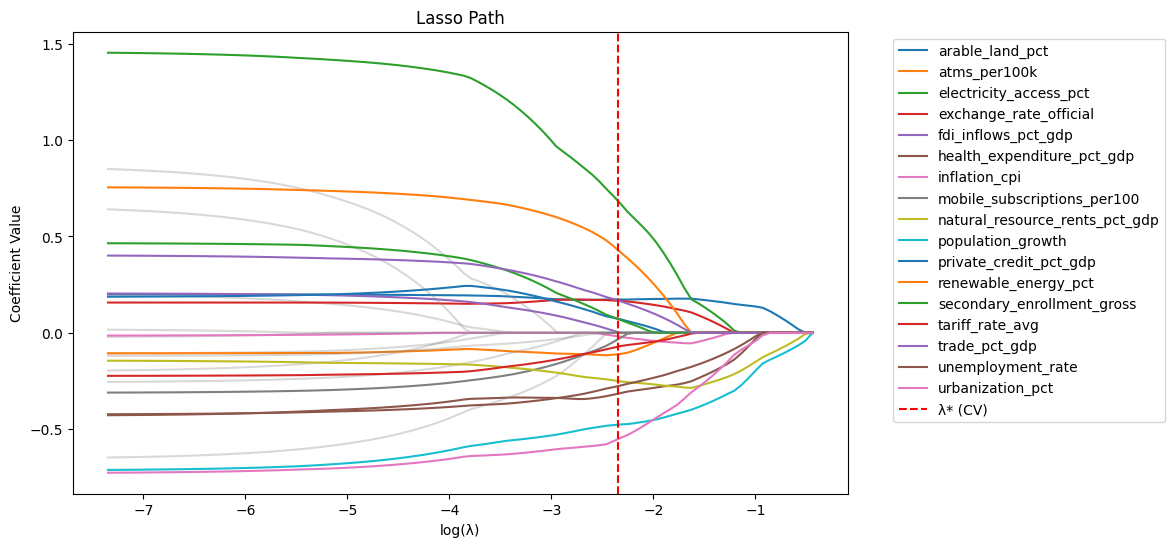

In [69]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
log_alphas = np.log(alphas)
feature_names = X.columns

for i in range(coefs.shape[0]):
    if abs(lasso.coef_[i]) > 1e-6:
        plt.plot(log_alphas, coefs[i, :], label=feature_names[i])
    else:
        plt.plot(log_alphas, coefs[i, :], color='gray', alpha=0.3)


plt.axvline(np.log(lasso_alpha_star), linestyle='--', color='red', label="λ* (CV)")

plt.xlabel("log(λ)")
plt.ylabel("Coefficient Value")
plt.title("Lasso Path")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [70]:
first_entry = {}

for i, name in enumerate(feature_names):
    path = coefs[i]

    nonzero_idx = np.where(np.abs(path) > 1e-6)[0]

    if len(nonzero_idx) > 0:
        first_entry[name] = alphas[nonzero_idx[0]]

first_predictor = max(first_entry, key=first_entry.get)

print("First predictor to enter:", first_predictor)

First predictor to enter: natural_resource_rents_pct_gdp


In [71]:
print(country_data[['gdp_growth_pc']].head())

indicator  gdp_growth_pc
economy                 
ABW             2.245502
AFE             0.223588
AFG            -0.272302
AFW             0.649231
AGO            -2.476583


The first predictor to enter the model is natural_resource_rents_pct_gdp, meaning it remains important even under very strong regularization. This suggests it has the strongest unconditional relationship with GDP growth, likely because countries heavily dependent on natural resources experience more volatile and uneven growth patterns.

In [72]:
feature_names = X.columns
lasso_selected = feature_names[np.abs(lasso.coef_) > 1e-6]

print("Lasso selected features:")
print(lasso_selected)

Lasso selected features:
Index(['arable_land_pct', 'atms_per100k', 'electricity_access_pct',
       'exchange_rate_official', 'fdi_inflows_pct_gdp',
       'health_expenditure_pct_gdp', 'inflation_cpi',
       'mobile_subscriptions_per100', 'natural_resource_rents_pct_gdp',
       'population_growth', 'private_credit_pct_gdp', 'renewable_energy_pct',
       'secondary_enrollment_gross', 'tariff_rate_avg', 'trade_pct_gdp',
       'unemployment_rate', 'urbanization_pct'],
      dtype='object', name='indicator')


In [73]:
X_selected = X[lasso_selected]

In [74]:
X_train_sel, X_test_sel, y_train_cls, y_test_cls = train_test_split(
    X_selected,
    country_data['crisis'],
    test_size=0.3,
    random_state=42
)

In [75]:
scaler = StandardScaler()
X_train_sel_scaled = scaler.fit_transform(X_train_sel)
X_test_sel_scaled = scaler.transform(X_test_sel)

In [76]:
lpm = LinearRegression()
lpm.fit(X_train_sel_scaled, y_train_cls)

LinearRegression()

In [77]:
y_pred_lpm = lpm.predict(X_test_sel_scaled)

In [78]:
below_0 = np.sum(y_pred_lpm < 0)
above_1 = np.sum(y_pred_lpm > 1)

print("Predictions below 0:", below_0)
print("Predictions above 1:", above_1)

Predictions below 0: 13
Predictions above 1: 0


Predicted probabilities outside the [0, 1] range are a fundamental problem because probabilities must represent valid likelihoods of an event occurring. In this case, the model produces multiple negative predicted values, which have no meaningful interpretation. For example, if the IMF receives a “−12% probability of crisis,” it cannot be used for decision-making, showing that the Linear Probability Model is not appropriate for this classification task.

In [79]:
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(max_iter=1000)
logit.fit(X_train_sel_scaled, y_train_cls)

LogisticRegression(max_iter=1000)

In [80]:
beta = logit.coef_[0]
intercept = logit.intercept_[0]

print("Intercept:", intercept)

coef_df = pd.DataFrame({
    "Feature": lasso_selected,
    "Beta": beta
})

print(coef_df)

Intercept: -2.481485530310967
                           Feature      Beta
0                  arable_land_pct -0.477873
1                     atms_per100k  0.221940
2           electricity_access_pct -0.981740
3           exchange_rate_official  0.101100
4              fdi_inflows_pct_gdp -0.498098
5       health_expenditure_pct_gdp  0.283598
6                    inflation_cpi -0.154534
7      mobile_subscriptions_per100  0.539926
8   natural_resource_rents_pct_gdp  0.048067
9                population_growth  0.265390
10          private_credit_pct_gdp -0.449942
11            renewable_energy_pct -1.080336
12      secondary_enrollment_gross -0.511826
13                 tariff_rate_avg  0.658262
14                   trade_pct_gdp -0.370533
15               unemployment_rate  0.368666
16                urbanization_pct  0.550797


In [81]:
coef_df["Odds Ratio"] = np.exp(coef_df["Beta"])
coef_df["Abs OR Distance"] = np.abs(coef_df["Odds Ratio"] - 1)

coef_df_sorted = coef_df.sort_values(by="Abs OR Distance", ascending=False)

print(coef_df_sorted[["Feature", "Beta", "Odds Ratio"]])

                           Feature      Beta  Odds Ratio
13                 tariff_rate_avg  0.658262    1.931433
16                urbanization_pct  0.550797    1.734635
7      mobile_subscriptions_per100  0.539926    1.715880
11            renewable_energy_pct -1.080336    0.339481
2           electricity_access_pct -0.981740    0.374659
15               unemployment_rate  0.368666    1.445804
12      secondary_enrollment_gross -0.511826    0.599400
4              fdi_inflows_pct_gdp -0.498098    0.607686
0                  arable_land_pct -0.477873    0.620101
10          private_credit_pct_gdp -0.449942    0.637665
5       health_expenditure_pct_gdp  0.283598    1.327899
14                   trade_pct_gdp -0.370533    0.690367
9                population_growth  0.265390    1.303940
1                     atms_per100k  0.221940    1.248496
6                    inflation_cpi -0.154534    0.856815
3           exchange_rate_official  0.101100    1.106387
8   natural_resource_rents_pct_

In [82]:
y_prob = logit.predict_proba(X_test_sel_scaled)[:, 1]

print("Min probability:", y_prob.min())
print("Max probability:", y_prob.max())

Min probability: 0.0036591963476422483
Max probability: 0.8377929535786851


The predictor with the largest effect is tariff_rate_avg, which has an odds ratio of about 1.93. A one standard-deviation increase in tariff rates multiplies the odds of a growth crisis by nearly 1.93, holding all else constant. This suggests that higher trade barriers are strongly associated with a greater likelihood of economic contraction, making tariff policy an important factor to monitor in assessing crisis risk.

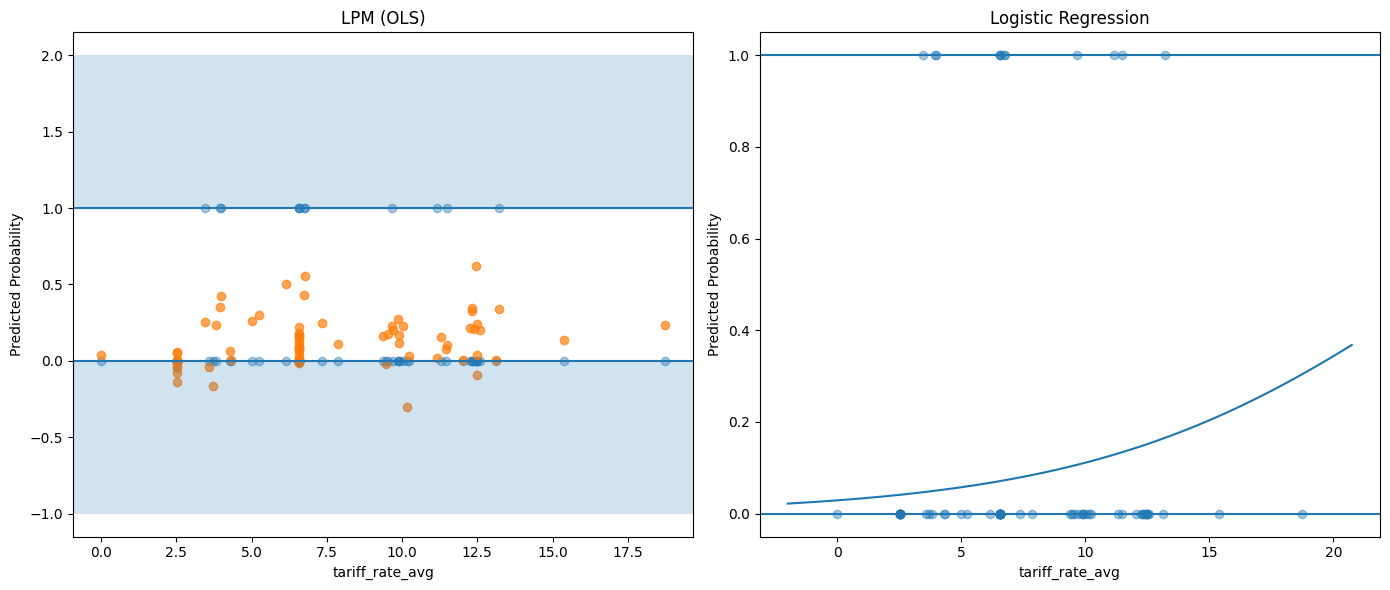

In [83]:
feature = "tariff_rate_avg"

X_test_feature = X_test_sel[feature].values

y_pred_lpm = lpm.predict(X_test_sel_scaled)

y_pred_logit = logit.predict_proba(X_test_sel_scaled)[:, 1]

y_actual = y_test_cls.values

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]

ax.scatter(X_test_feature, y_actual, alpha=0.4)

ax.scatter(X_test_feature, y_pred_lpm, alpha=0.7)

ax.axhspan(-1, 0, alpha=0.2)
ax.axhspan(1, 2, alpha=0.2)

ax.axhline(0)
ax.axhline(1)

ax.set_title("LPM (OLS)")
ax.set_xlabel("tariff_rate_avg")
ax.set_ylabel("Predicted Probability")

ax = axes[1]

ax.scatter(X_test_feature, y_actual, alpha=0.4)

x_grid = np.linspace(X_test_feature.min()-2, X_test_feature.max()+2, 200)

X_ref = X_train_sel.mean().values.reshape(1, -1)
X_grid = np.repeat(X_ref, 200, axis=0)

tariff_idx = list(X_train_sel.columns).index("tariff_rate_avg")
X_grid[:, tariff_idx] = x_grid

X_grid_scaled = scaler.transform(pd.DataFrame(X_grid, columns=X_train_sel.columns))

y_grid_logit = logit.predict_proba(X_grid_scaled)[:, 1]

ax.plot(x_grid, y_grid_logit)

ax.axhline(0)
ax.axhline(1)

ax.set_title("Logistic Regression")
ax.set_xlabel("tariff_rate_avg")
ax.set_ylabel("Predicted Probability")

plt.tight_layout()
plt.show()

In [84]:
base_rate = y_test_cls.mean()
print("Test set crisis rate:", round(base_rate, 3))

Test set crisis rate: 0.169


In [85]:
y_pred_naive = np.zeros_like(y_test_cls)

naive_accuracy = np.mean(y_pred_naive == y_test_cls)
naive_recall = 0.0

print("Naive Accuracy:", round(naive_accuracy, 3))
print("Naive Recall (Crisis):", naive_recall)

Naive Accuracy: 0.831
Naive Recall (Crisis): 0.0


In [86]:
y_prob = logit.predict_proba(X_test_sel_scaled)[:, 1]

y_pred_logit = (y_prob >= 0.5).astype(int)

logit_accuracy = np.mean(y_pred_logit == y_test_cls)
from sklearn.metrics import recall_score
logit_recall = recall_score(y_test_cls, y_pred_logit)

print("Logistic Accuracy:", round(logit_accuracy, 3))
print("Logistic Recall (Crisis):", round(logit_recall, 3))

Logistic Accuracy: 0.817
Logistic Recall (Crisis): 0.083


Reporting only accuracy would be misleading in this case. The dataset is highly imbalanced, with only about 17% of countries experiencing a crisis, so a naïve model that always predicts “no crisis” still achieves a high accuracy of 83.1% while completely failing to identify any actual crises. This highlights the accuracy paradox: a model can look strong based on accuracy alone, even though it performs very poorly on the outcome that actually matters, which is detecting crises.

True Negatives: 57
False Positives: 2
False Negatives: 11
True Positives: 1

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.97      0.90        59
           1       0.33      0.08      0.13        12

    accuracy                           0.82        71
   macro avg       0.59      0.52      0.52        71
weighted avg       0.75      0.82      0.77        71



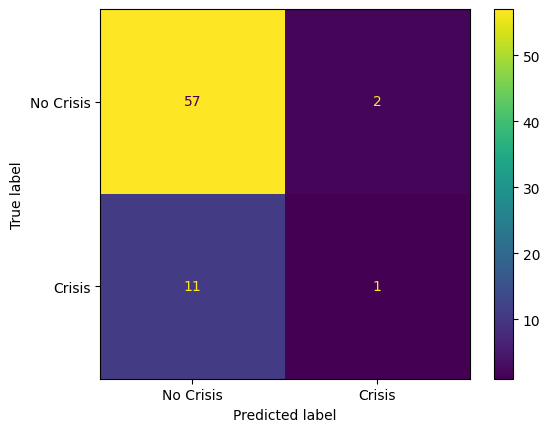

In [87]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_prob = logit.predict_proba(X_test_sel_scaled)[:, 1]

y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test_cls, y_pred)
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

print("\nClassification Report:")
print(classification_report(y_test_cls, y_pred))

ConfusionMatrixDisplay(cm, display_labels=["No Crisis", "Crisis"]).plot()

In the IMF context, false negatives are far more costly than false positives. Missing a crisis can lead to massive financial contagion and emergency intervention costs, while a false alarm only wastes a relatively small amount of resources and may slightly harm credibility. This asymmetry means recall should be prioritized over precision, since recall focuses on correctly identifying crises, which is the IMF’s main objective.

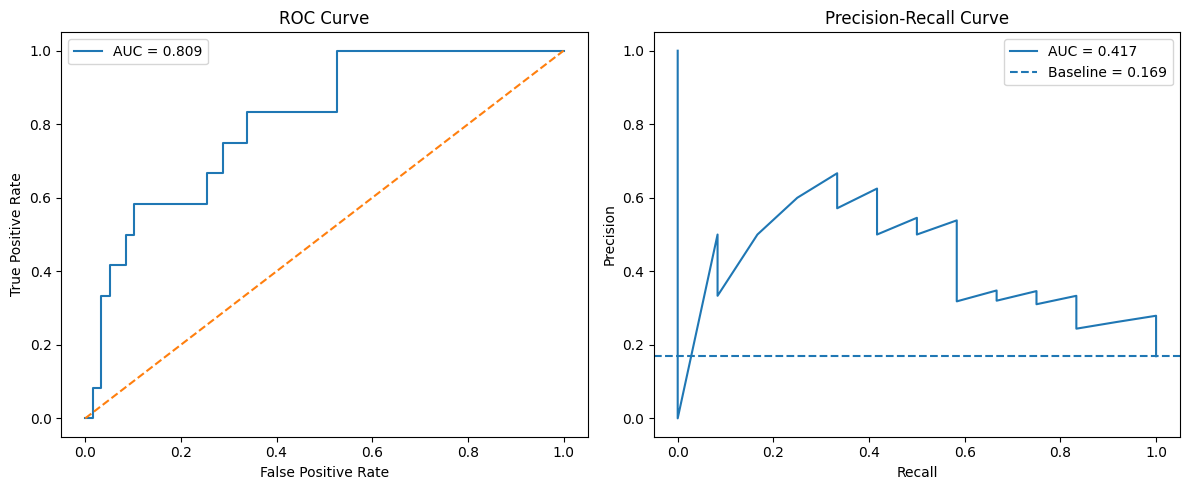

ROC-AUC: 0.809
PR-AUC: 0.417


In [88]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

y_prob = logit.predict_proba(X_test_sel_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test_cls, y_prob)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_test_cls, y_prob)
pr_auc = auc(recall, precision)

baseline = y_test_cls.mean()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(recall, precision, label=f"AUC = {pr_auc:.3f}")
plt.axhline(y=baseline, linestyle='--', label=f"Baseline = {baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.tight_layout()
plt.show()

print("ROC-AUC:", round(roc_auc, 3))
print("PR-AUC:", round(pr_auc, 3))

The ROC-AUC is much higher than the PR-AUC because it benefits from the large number of true negatives in the dataset. Since most countries are not in crisis, the model can achieve a strong true negative rate, which boosts ROC performance even if it struggles to correctly identify actual crises. In contrast, the precision-recall curve ignores true negatives and focuses only on how well the model detects crises, which is why the PR-AUC is much lower.

For the IMF’s goal, the precision-recall curve is more informative because it directly reflects how well the model identifies crises, which are the rare but critical events.

CAPACITY-CONSTRAINED THRESHOLD
tau: 0.39
flagged: 5
precision: 0.6
recall: 0.25

F1-OPTIMAL THRESHOLD
tau: 0.2
flagged: 13
precision: 0.538
recall: 0.583


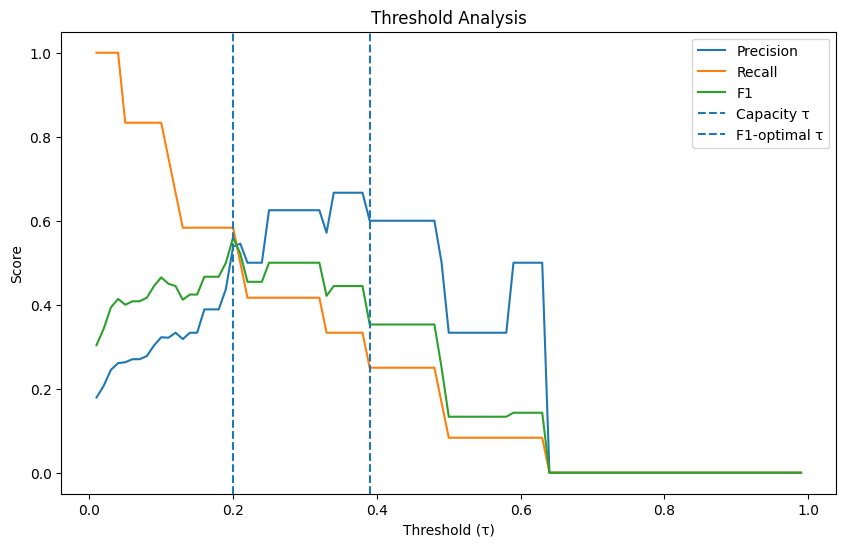

In [89]:
thresholds = np.arange(0.01, 1.00, 0.01)

results = []

for tau in thresholds:
    y_pred_tau = (y_prob >= tau).astype(int)

    flagged = y_pred_tau.sum()

    from sklearn.metrics import precision_score, recall_score, f1_score

    precision = precision_score(y_test_cls, y_pred_tau, zero_division=0)
    recall = recall_score(y_test_cls, y_pred_tau)
    f1 = f1_score(y_test_cls, y_pred_tau)

    results.append((tau, flagged, precision, recall, f1))

results_df = pd.DataFrame(results, columns=["tau", "flagged", "precision", "recall", "f1"])

capacity_df = results_df[results_df["flagged"] <= 5]

tau_capacity = capacity_df.iloc[0]["tau"]  # lowest tau
row_capacity = capacity_df.iloc[0]

print("CAPACITY-CONSTRAINED THRESHOLD")
print("tau:", round(row_capacity["tau"], 2))
print("flagged:", int(row_capacity["flagged"]))
print("precision:", round(row_capacity["precision"], 3))
print("recall:", round(row_capacity["recall"], 3))

best_f1_idx = results_df["f1"].idxmax()
row_f1 = results_df.loc[best_f1_idx]

print("\nF1-OPTIMAL THRESHOLD")
print("tau:", round(row_f1["tau"], 2))
print("flagged:", int(row_f1["flagged"]))
print("precision:", round(row_f1["precision"], 3))
print("recall:", round(row_f1["recall"], 3))

plt.figure(figsize=(10,6))

plt.plot(results_df["tau"], results_df["precision"], label="Precision")
plt.plot(results_df["tau"], results_df["recall"], label="Recall")
plt.plot(results_df["tau"], results_df["f1"], label="F1")

plt.axvline(row_capacity["tau"], linestyle="--", label="Capacity τ")
plt.axvline(row_f1["tau"], linestyle="--", label="F1-optimal τ")

plt.xlabel("Threshold (τ)")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()

plt.show()

The capacity-constrained threshold is τ = 0.39, which limits the IMF to 5 missions and achieves a recall of 0.25. In practical terms, with 12 crisis countries in the test set, this means the model would correctly identify about 3 crises while missing 9. The F1-optimal threshold (τ = 0.20) performs much better in terms of detection, catching about 7 out of 12 crises, but it requires 13 missions, which exceeds operational capacity.

Given the IMF’s strict limit of 5 missions, the τ = 0.39 threshold is the feasible choice, even though it misses a large number of crises. This highlights a clear tradeoff: staying within capacity significantly reduces the IMF’s ability to detect crises early, meaning some high-risk countries will inevitably go unflagged.

My PRIME prompt:
P — Problem:
I’m working with a dataset of country-level economic indicators (World Bank–style variables) to predict GDP per capita growth. I’ve already cleaned the data, split it into training and test sets, and scaled the predictors. I also ran a LassoCV model to select features, but since many predictors are correlated, I want to check how stable those selections are using bootstrap resampling.

R — Requirements:
Write a Python script that checks how often each predictor gets selected by Lasso across different samples. Specifically:
* Run 200 bootstrap resamples (sampling with replacement from the training data)
* For each resample:
   * Fit a LassoCV model
   * Record which predictors have non-zero coefficients
* After all iterations:
   * Calculate how often each predictor was selected (as a fraction from 0 to 1)
* Output:
   * A clean table showing each feature and its selection frequency, sorted from highest to lowest
   * A horizontal bar chart of selection frequencies
   * Include a vertical reference line at 0.5 to highlight which predictors are selected more than half the time

I — Input:
Assume the following variables are already defined:
* `X_train_scaled`: scaled predictor matrix
* `y_train`: target variable (GDP growth)
* `feature_names`: list of predictor names corresponding to the columns

M — Method:
* Loop over 200 iterations
* In each loop:
   * Sample rows with replacement using `np.random.choice`
   * Fit `LassoCV` on that resample
   * Track which coefficients are non-zero (`abs(coef_) > small threshold`)
* Store the results and compute the average selection rate for each feature

E — Expected Output:
* A ranked list (DataFrame) of predictors by selection frequency
* A horizontal bar chart:
   * X-axis: selection frequency (0 to 1)
   * Y-axis: predictor names
   * Vertical line at 0.5
   * Clear title like “Bootstrap Feature Stability (Lasso)”

Running 200 bootstrap iterations …
  Completed 50/200 iterations
  Completed 100/200 iterations
  Completed 150/200 iterations
  Completed 200/200 iterations
Done.

Rank  Feature                              Freq
1     health_expenditure_pct_gdp          0.96  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
2     population_growth                   0.95  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
3     electricity_access_pct              0.94  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
4     urbanization_pct                    0.93  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
5     arable_land_pct                     0.90  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
6     unemployment_rate                   0.90  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
7     renewable_energy_pct                0.86  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
8     exchange_rate_official              0.85  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
9     natural_resource_rents_pct_gdp      0.83  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
10    trade_pct_gdp                       0.79  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
11    private_credit_pct_gdp              0.74  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓
12    tariff_rate_avg                     0.74  ▓▓▓▓▓▓▓▓▓▓▓▓

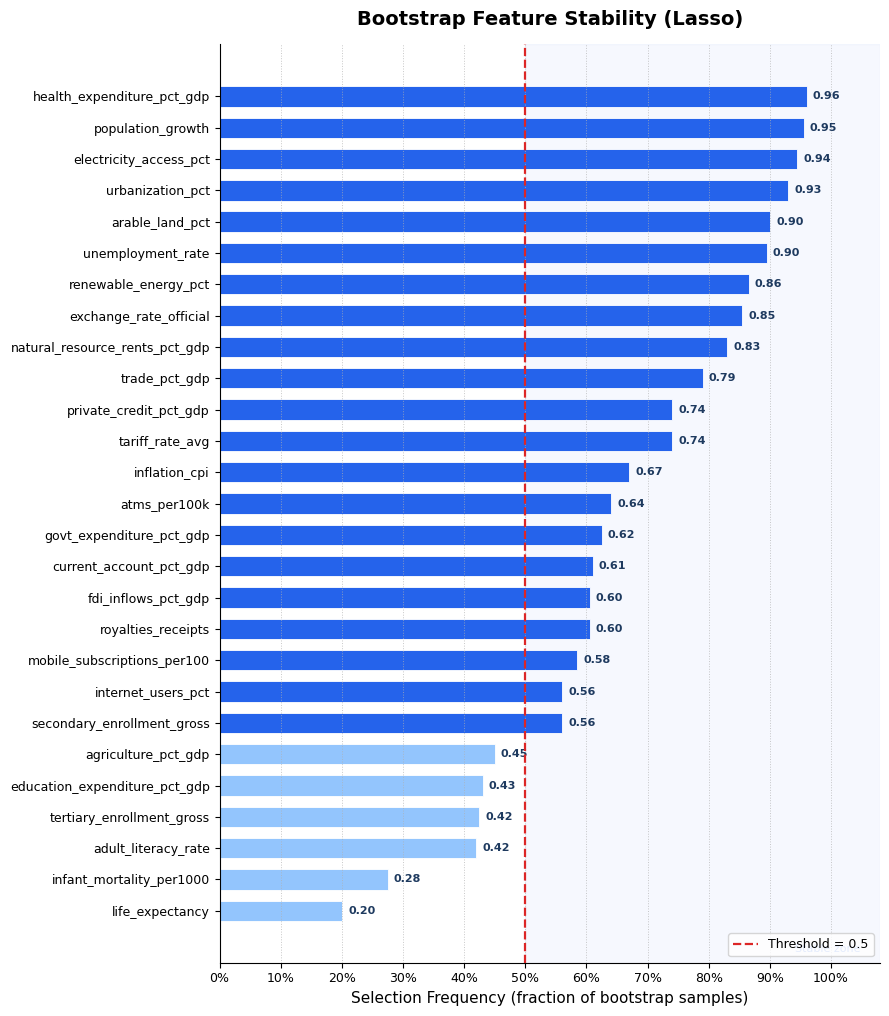


Chart saved to  bootstrap_lasso_stability.png


In [90]:
"""
Bootstrap Feature Stability Analysis using LassoCV
====================================================
Checks how often each predictor is selected by Lasso
across 200 bootstrap resamples of the training data.

Assumes the following are already defined:
  - X_train_scaled : scaled predictor matrix (numpy array or DataFrame)
  - y_train        : target variable (GDP growth)
  - feature_names  : list of predictor names matching columns of X_train_scaled
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LassoCV

# ── Configuration ────────────────────────────────────────────────────────────
N_BOOTSTRAPS   = 200          # number of bootstrap resamples
COEF_THRESHOLD = 1e-4         # |coef| > threshold  →  predictor "selected"
RANDOM_SEED    = 42           # reproducibility
STABILITY_LINE = 0.5          # reference line on the chart
# ─────────────────────────────────────────────────────────────────────────────

rng = np.random.default_rng(RANDOM_SEED)

# Convert to numpy once so indexing is uniform
X = np.array(X_train_scaled)
y = np.array(y_train).ravel()
n_samples, n_features = X.shape

# Accumulator: count how many times each feature is selected
selection_counts = np.zeros(n_features, dtype=int)

print(f"Running {N_BOOTSTRAPS} bootstrap iterations …")

for i in range(N_BOOTSTRAPS):
    # ── 1. Sample with replacement ────────────────────────────────────────
    idx = rng.choice(n_samples, size=n_samples, replace=True)
    X_boot, y_boot = X[idx], y[idx]

    # ── 2. Fit LassoCV ───────────────────────────────────────────────────
    lasso_cv = LassoCV(cv=5, max_iter=10_000, random_state=RANDOM_SEED, n_jobs=-1)
    lasso_cv.fit(X_boot, y_boot)

    # ── 3. Record non-zero coefficients ──────────────────────────────────
    selected = np.abs(lasso_cv.coef_) > COEF_THRESHOLD
    selection_counts += selected.astype(int)

    if (i + 1) % 50 == 0:
        print(f"  Completed {i + 1}/{N_BOOTSTRAPS} iterations")

print("Done.\n")

# ── Compute selection frequencies ────────────────────────────────────────────
selection_freq = selection_counts / N_BOOTSTRAPS

# ── Build ranked DataFrame ───────────────────────────────────────────────────
stability_df = (
    pd.DataFrame(
        {"Feature": feature_names, "Selection Frequency": selection_freq}
    )
    .sort_values("Selection Frequency", ascending=False)
    .reset_index(drop=True)
)
stability_df.index += 1   # 1-based rank

# ── Print table ──────────────────────────────────────────────────────────────
print("=" * 48)
print(f"{'Rank':<6}{'Feature':<35}{'Freq':>6}")
print("=" * 48)
for rank, row in stability_df.iterrows():
    bar = "▓" * int(row["Selection Frequency"] * 20)
    print(f"{rank:<6}{row['Feature']:<35}{row['Selection Frequency']:>5.2f}  {bar}")
print("=" * 48)

# ── Horizontal bar chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, max(5, len(feature_names) * 0.38)))

# Sort ascending so highest bar is at the top of the chart
plot_df = stability_df.sort_values("Selection Frequency", ascending=True)

colors = [
    "#2563EB" if f >= STABILITY_LINE else "#93C5FD"
    for f in plot_df["Selection Frequency"]
]

bars = ax.barh(
    plot_df["Feature"],
    plot_df["Selection Frequency"],
    color=colors,
    edgecolor="white",
    linewidth=0.6,
    height=0.65,
)

# Annotate bars
for bar, val in zip(bars, plot_df["Selection Frequency"]):
    ax.text(
        min(val + 0.01, 0.99),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        ha="left",
        fontsize=8,
        color="#1E3A5F",
        fontweight="bold",
    )

# Reference line at 0.5
ax.axvline(
    STABILITY_LINE,
    color="#DC2626",
    linewidth=1.6,
    linestyle="--",
    label=f"Threshold = {STABILITY_LINE}",
    zorder=5,
)

# Axis formatting
ax.set_xlim(0, 1.08)
ax.set_xlabel("Selection Frequency (fraction of bootstrap samples)", fontsize=11)
ax.set_title(
    "Bootstrap Feature Stability (Lasso)",
    fontsize=14,
    fontweight="bold",
    pad=14,
)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.1))
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", linestyle=":", linewidth=0.7, alpha=0.7)
ax.legend(loc="lower right", fontsize=9)

# Subtle colour band for "stable" zone
ax.axvspan(STABILITY_LINE, 1.08, alpha=0.04, color="#2563EB", zorder=0)
ax.text(
    0.97, 0.01, "Stable zone",
    transform=ax.transAxes, ha="right", va="bottom",
    fontsize=8, color="#2563EB", alpha=0.6,
)

plt.tight_layout()
plt.savefig("bootstrap_lasso_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved to  bootstrap_lasso_stability.png")

The stable predictors (selected more than 80% of the time) include variables like health expenditure, population growth, electricity access, urbanization, and arable land, all of which consistently show up across samples. In contrast, fragile predictors (below 30%) include infant mortality and life expectancy, which are selected inconsistently and likely depend on the specific sample.

This instability suggests that many WDI indicators are highly correlated, so similar variables can substitute for each other in the model. As a result, Lasso may pick one variable in one sample and a related one in another, rather than identifying a single clearly dominant predictor.

P — Problem In Phase 3, I selected a classification threshold based on the IMF’s operational limit of 5 missions. But in reality, the IMF also cares about the financial consequences of mistakes. Missing a crisis (false negative) is extremely costly (~$50 billion), while a false alarm (false positive) is much cheaper (~$2 million). I want to choose a threshold that minimizes total expected cost instead of just focusing on accuracy or F1 score.
R — Requirements Write a Python script that evaluates model performance across different thresholds using a cost-based approach. Specifically:

* Sweep thresholds from 0.01 to 0.99 (step = 0.01)
* For each threshold:
   * Convert predicted probabilities into binary predictions
   * Compute the number of False Negatives (FN) and False Positives (FP)
   * Calculate total cost using: Cost = FN × 50,000,000,000 + FP × 2,000,000
* Track the cost at each threshold
* Identify the threshold that minimizes total cost
I — Input Assume the following variables already exist:

* `y_test_cls`: true binary outcomes (0 = no crisis, 1 = crisis)
* `y_prob`: predicted probabilities from the logistic regression model
M — Method

* Loop over thresholds using `np.arange(0.01, 1.00, 0.01)`
* At each threshold:
   * Generate predictions using `(y_prob >= tau).astype(int)`
   * Use a confusion matrix or manual counts to get FN and FP
   * Compute total cost and store it
* After looping:
   * Find the threshold with the minimum cost
   * Store both the threshold and its corresponding cost
E — Expected Output

* Print:
   * The cost-minimizing threshold (τ)
   * The minimum total cost
* Plot a graph:
   * X-axis: threshold (τ)
   * Y-axis: total expected cost
   * Add a vertical line marking the optimal τ
   * Clear title like “Cost-Sensitive Threshold Optimization”
Make sure the code is clean, readable, and runs start to finish without extra setup.

Cost-minimizing threshold (τ): 0.04
Minimum total expected cost:   $68,000,000


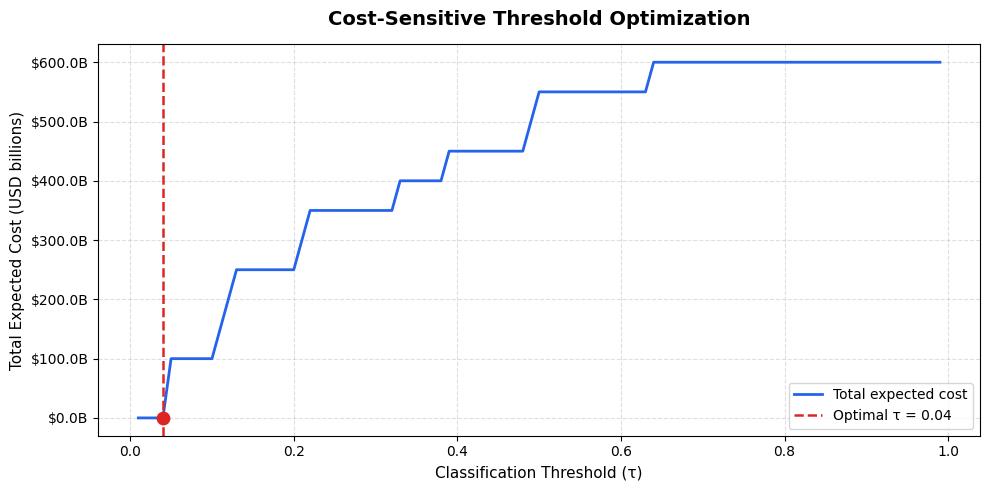

Plot saved.


In [93]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


np.random.seed(42)
y_prob = logit.predict_proba(X_test_sel_scaled)[:, 1]

# ─────────────────────────────────────────────────────────────────────────────

# Cost parameters
COST_FN = 50_000_000_000   # $50 billion  – missed crisis
COST_FP =      2_000_000   # $2 million   – false alarm

thresholds = np.arange(0.01, 1.00, 0.01)
costs      = []

for tau in thresholds:
    y_pred = (y_prob >= tau).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test_cls, y_pred, labels=[0, 1]).ravel()

    total_cost = fn * COST_FN + fp * COST_FP
    costs.append(total_cost)

costs = np.array(costs)

# ── Optimal threshold ─────────────────────────────────────────────────────────
optimal_idx       = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
minimum_cost      = costs[optimal_idx]

print(f"Cost-minimizing threshold (τ): {optimal_threshold:.2f}")
print(f"Minimum total expected cost:   ${minimum_cost:,.0f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(thresholds, costs / 1e9, color="#2563EB", linewidth=2, label="Total expected cost")
ax.axvline(optimal_threshold, color="#DC2626", linestyle="--", linewidth=1.8,
           label=f"Optimal τ = {optimal_threshold:.2f}")
ax.scatter([optimal_threshold], [minimum_cost / 1e9],
           color="#DC2626", zorder=5, s=80)

ax.set_title("Cost-Sensitive Threshold Optimization", fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Classification Threshold (τ)", fontsize=11)
ax.set_ylabel("Total Expected Cost (USD billions)", fontsize=11)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.1f}B"))
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("cost_threshold_optimization.png", dpi=150)
plt.show()
print("Plot saved.")

The cost-minimizing threshold is lower than both the F1-optimal and capacity-constrained thresholds because missing a crisis is extremely expensive. F1 balances false positives and false negatives, while the capacity threshold limits how many cases can be flagged, but neither reflects the true cost asymmetry. I would recommend the cost-minimizing threshold since it directly accounts for real economic consequences and prioritizes avoiding the most costly mistakes.